# Linear Regression Project — Predicting Student Final Scores

## Student Guide

### Project goal
Build a machine learning model that predicts a student's **final exam score** from academic and study-related information.

You will progress from **simple linear regression** to **multiple linear regression**, then evaluate and interpret your model.

### Learning objectives
By the end of this lab, you should be able to:

- Identify a regression problem.
- Separate features (`X`) from a continuous target (`y`).
- Explore relationships between variables.
- Train a simple linear regression model.
- Understand slope, intercept, predictions, and residuals.
- Split data into training and testing sets.
- Evaluate regression models using MAE, MSE, RMSE, and R².
- Train a multiple linear regression model.
- Interpret regression coefficients.
- Compare models.
- Investigate residuals and unusual observations.


## 1. Problem Understanding

A school wants to estimate a student's final exam score using information available before the final exam.

### Main question

> Can we predict `final_score` from study habits and academic information?

### First think before coding

**Question 1:** Is this classification or regression? Why?

**Your answer:**

> This is a regression problem because the target variable, final_score, is a continuous numerical value


## 2. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



## 3. Load the Dataset

The provided local dataset is:

`data/student_performance.csv`

If you move this notebook to another folder, update the path accordingly.


In [14]:
df = pd.read_excel("/content/student_performance.xlsx")



In [13]:
df.head()

,student_id,study_hours,attendance,previous_score,assignments_completed,sleep_hours,practice_tests,final_score
0,1,16.8,83.5,58.2,76.5,6.5,4,100.0
1,2,8.8,94.2,54.8,83.8,8.1,2,98.5
2,3,19.5,95.4,74.8,89.4,7.3,1,100.0
3,4,20.6,71.2,75.3,91.4,6.2,3,100.0
4,5,3.3,81.2,88.0,85.6,6.0,5,91.4


## 4. Understand the Data

In [15]:
df.shape



(800, 8)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             800 non-null    int64  
 1   study_hours            800 non-null    float64
 2   attendance             800 non-null    float64
 3   previous_score         800 non-null    float64
 4   assignments_completed  800 non-null    float64
 5   sleep_hours            800 non-null    float64
 6   practice_tests         800 non-null    int64  
 7   final_score            800 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 50.1 KB


In [17]:
df.describe()


,student_id,study_hours,attendance,previous_score,assignments_completed,sleep_hours,practice_tests,final_score
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000,800.000000
mean,400.5000,14.826250,83.319250,69.359625,81.130250,7.045500,3.93125,98.083750
std,231.0844,5.932346,8.718908,14.064137,11.879914,1.097867,2.00538,4.508722
min,1.0000,1.000000,56.400000,35.000000,42.800000,4.000000,0.00000,46.000000
25%,200.7500,10.700000,77.500000,60.075000,73.775000,6.300000,3.00000,99.375000
50%,400.5000,14.950000,84.100000,69.900000,81.200000,7.000000,4.00000,100.000000
75%,600.2500,18.700000,89.400000,78.600000,89.900000,7.800000,5.00000,100.000000
max,800.0000,32.500000,100.000000,100.000000,100.000000,10.000000,12.00000,100.000000


In [18]:
df.isnull().sum()



,0
student_id,0
study_hours,0
attendance,0
previous_score,0
assignments_completed,0
sleep_hours,0
practice_tests,0
final_score,0


### Questions

1. How many observations are there?
2. What is the target variable?
3. Which columns could be useful predictors?
4. Are there any missing values?

Write your answers below.

> **Answer:**
1. There are (800, 8) observations in the dataset.

2. The target variable is final_score.

3. Useful predictors include study_hours, attendance, previous_score, assignments_completed, sleep_hours, and practice_tests.

4. There are no missing values in the dataset.


## 5. Explore the Target Variable

Before building a model, understand what you are trying to predict.


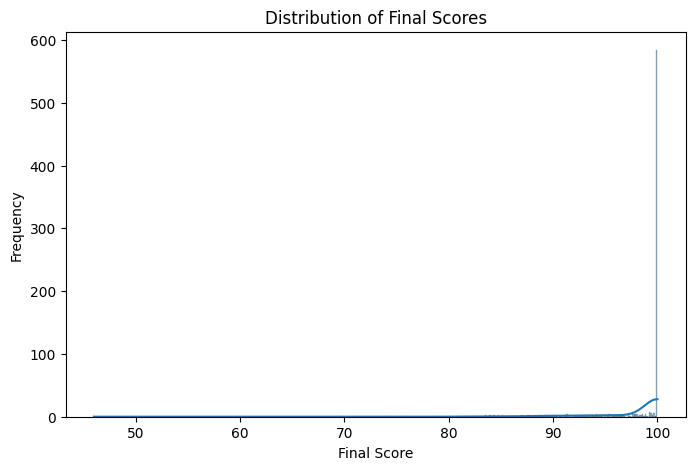

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df["final_score"], kde=True)
plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()


In [20]:
print("Mean:", df["final_score"].mean())
print("Minimum:", df["final_score"].min())
print("Maximum:", df["final_score"].max())
print("Standard Deviation:", df["final_score"].std())


Mean: 98.08375
Minimum: 46.0
Maximum: 100.0
Standard Deviation: 4.508721731496114


## 6. Explore Relationships

Start with the simplest possible regression problem:

> Can `study_hours` predict `final_score`?

Create a scatter plot with:

- x-axis: `study_hours`
- y-axis: `final_score`

Add a clear title and axis labels.


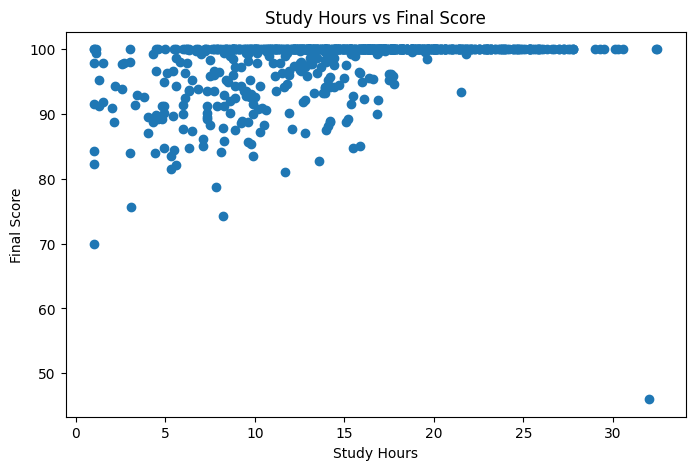

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(df["study_hours"], df["final_score"])
plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.show()

### Think about the plot

- Does the relationship look approximately linear?
- Is the relationship positive or negative?
- Are there unusual points?
- Would a straight line be a reasonable first model?

**Your answer:**
The relationship appears to be approximately linear and positive. Students who study more hours tend to have higher final scores. There may be some unusual observations, but a straight line seems to be a reasonable first model.


## 7. Correlation

Calculate the correlation between `study_hours` and `final_score`.

Remember:

> Correlation measures the strength and direction of a linear relationship. It does not prove causation.


In [22]:
correlation = df["study_hours"].corr(df["final_score"])
print("Correlation:", correlation)


Correlation: 0.377948962389567


## 8. Simple Linear Regression

We will start with **one feature**:

`study_hours`

and one target:

`final_score`.

Conceptually, our model has the form:

`predicted_score = intercept + slope × study_hours`

### Step 1 — Create X and y

`X` should contain the input feature.

`y` should contain the target.


In [23]:
X = df[["study_hours"]]
y = df["final_score"]



## 9. Train/Test Split

We need two sets:

- **Training data:** used to learn the model.
- **Testing data:** used to evaluate how well the model generalizes to unseen data.

Use an 80/20 split and `random_state=42`.


In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


### Question

Why should we not train the model and evaluate it on exactly the same observations?

**Your answer:**
We should keep the test data separate because evaluating the model on the same data used for training can give an overly optimistic estimate of its performance. The test set helps measure how well the model generalizes to unseen data.


## 10. Train the Linear Regression Model

In [28]:
from sklearn.linear_model import LinearRegression


In [29]:
model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

## 11. Understand the Learned Line

The model has two important values:

- `intercept_`
- `coef_`

Find them and explain what they mean.


In [30]:
print("Intercept:", model.intercept_)

Intercept: 94.03115408761576


In [31]:
print("Coefficient:", model.coef_[0])

Coefficient: 0.2719165104044684


### Interpretation

Complete this sentence:

> For every additional hour of study, the model predicts approximately 0.2719165104044684 points change in final score, assuming the relationship represented by the model.

**Your answer:** TODO


## 12. Make Predictions

In [32]:
y_pred = model.predict(X_test)


In [33]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)


,Actual,Predicted
0,99.4,94.330262
1,100.0,98.898460
2,100.0,99.061610
3,100.0,98.844076
4,99.9,97.538877
5,100.0,98.164285
6,100.0,97.158194
7,100.0,99.877359
8,100.0,100.149276
9,100.0,99.877359


## 13. Visualize the Regression Line

Create a scatter plot of the test observations and draw the model's regression line.

This should help you visually connect the data, predictions, and fitted line.


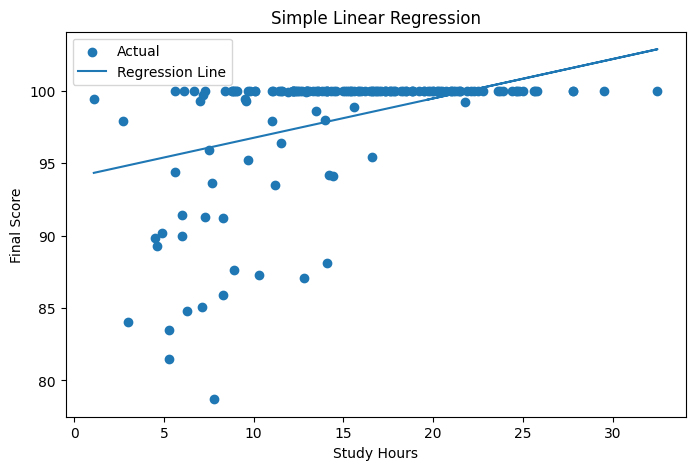

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test["study_hours"], y_test, label="Actual")

plt.plot(
    X_test["study_hours"],
    y_pred,
    label="Regression Line"
)

plt.title("Simple Linear Regression")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.legend()
plt.show()


## 14. Evaluate the Model

Calculate:

- MAE
- MSE
- RMSE
- R²

Do not only calculate them. Explain what each metric tells you.


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [36]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 2.5965998295530293
MSE: 14.477418360822478
RMSE: 3.804920283110078
R²: 0.22250303593555287


### Explain the metrics

**MAE:** Measures the average absolute prediction error in the same units as the target.

**MSE:** Measures the average squared prediction error and gives more weight to large errors.

**RMSE:** Measures the typical prediction error in the same units as the target and is more sensitive to large errors than MAE.

**R²:**  Measures the proportion of variance in the target variable that is explained by the regression model.


# Part 2 — Multiple Linear Regression

The simple model uses only study hours.

Now ask:

> Can we improve prediction by using several useful features?

We will use:

- `study_hours`
- `attendance`
- `previous_score`
- `assignments_completed`
- `sleep_hours`
- `practice_tests`


## 15. Prepare Multiple Features

In [37]:
features = [
    "study_hours",
    "attendance",
    "previous_score",
    "assignments_completed",
    "sleep_hours",
    "practice_tests"
]


In [38]:
X_multiple = df[features]
y = df["final_score"]



## 16. Split and Train the Multiple Regression Model

In [39]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple,
    y,
    test_size=0.2,
    random_state=42
)



In [40]:
multiple_model = LinearRegression()

multiple_model.fit(X_train_m, y_train_m)



LinearRegression()

## 17. Evaluate the Multiple Regression Model

In [42]:
y_pred_m = multiple_model.predict(X_test_m)


In [43]:
mae_m = mean_absolute_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_m))
r2_m = r2_score(y_test_m, y_pred_m)

print("Multiple Regression MAE:", mae_m)
print("Multiple Regression RMSE:", rmse_m)
print("Multiple Regression R²:", r2_m)


Multiple Regression MAE: 2.4656215688112253
Multiple Regression RMSE: 3.3464291918544875
Multiple Regression R²: 0.39858970597383314


## 18. Compare the Two Models

Create a small DataFrame with:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Simple Regression | | | |
| Multiple Regression | | | |

Then answer:

1. Which model performs better?
2. Why might additional useful features improve the model?
3. Does adding features automatically guarantee a better model?

**Your answer:**
1. The Multiple Regression model performs better than the Simple Regression model because it has a lower MAE and RMSE and a higher R².

2. Additional useful features can provide more information about the student's performance, allowing the model to make more accurate predictions.

3. No. Adding features does not automatically guarantee a better model. Irrelevant or noisy features may not improve performance and can sometimes lead to overfitting.


In [44]:
comparison_df = pd.DataFrame({
    "Model": ["Simple Regression", "Multiple Regression"],
    "MAE": [mae, mae_m],
    "RMSE": [rmse, rmse_m],
    "R²": [r2, r2_m]
})

comparison_df


,Model,MAE,RMSE,R²
0,Simple Regression,2.596600,3.804920,0.222503
1,Multiple Regression,2.465622,3.346429,0.398590


## 19. Interpret Multiple Regression Coefficients

Create a table containing:

- feature name
- coefficient

Then choose at least **three coefficients** and explain their meaning.

Important:

> A coefficient describes the model's estimated change in the target when that feature increases by one unit, while the other included features are held constant.

Also remember:

> A regression coefficient does not automatically prove causation.


In [45]:
coefficient_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": multiple_model.coef_
})

coefficient_df


,Feature,Coefficient
0,study_hours,0.289905
1,attendance,0.048842
2,previous_score,0.128416
3,assignments_completed,0.041090
4,sleep_hours,0.358576
5,practice_tests,0.304097


## 20. Residual Analysis

A residual is:

`actual value - predicted value`

Calculate the residuals for the multiple regression model.

Then:

1. Plot residuals against predicted values.
2. Draw a horizontal line at zero.
3. Look for obvious patterns.


In [46]:
residuals = y_test_m - y_pred_m


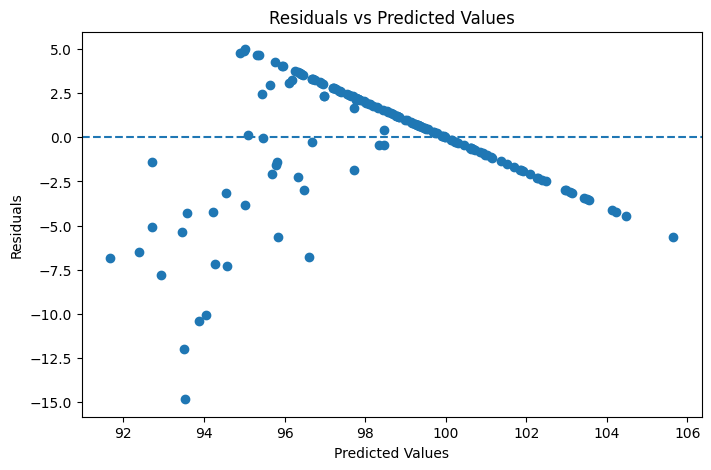

In [47]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred_m, residuals)

plt.axhline(y=0, linestyle="--")

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()


### Questions

- Are the residuals centered roughly around zero?
- Do you see a strong pattern?
- Do you notice unusual observations?

**Your answer:**  

1.   No. Most residuals are below zero, especially at lower predicted values.
2.   Yes. There is a clear downward/linear pattern, meaning the residuals are not randomly scattered.


1.   Yes. There are several outliers, especially residuals around −10 to −15.








## 21. Investigate Unusual Observations

Look at observations with the largest absolute residuals.

Do not immediately delete them.

Instead ask:

> Is this observation an error, a valid unusual student, or something the model cannot explain well?



In [48]:
residual_analysis = X_test_m.copy()

residual_analysis["Actual"] = y_test_m.values
residual_analysis["Predicted"] = y_pred_m
residual_analysis["Residual"] = residuals.values
residual_analysis["Absolute_Residual"] = np.abs(residuals.values)

residual_analysis.sort_values(
    "Absolute_Residual",
    ascending=False
).head(10)


,study_hours,attendance,previous_score,assignments_completed,sleep_hours,practice_tests,Actual,Predicted,Residual,Absolute_Residual
84,7.8,78.2,54.7,72.0,6.9,4,78.7,93.540871,-14.840871,14.840871
738,5.3,93.4,57.0,79.6,7.6,1,81.5,93.504857,-12.004857,12.004857
666,5.3,89.5,52.0,74.7,7.3,6,83.5,93.883864,-10.383864,10.383864
377,3.0,86.0,72.1,80.1,6.5,1,84.0,94.041848,-10.041848,10.041848
96,7.1,79.8,60.5,64.1,6.9,1,85.1,92.923996,-7.823996,7.823996
486,10.3,83.1,51.4,77.9,7.6,4,87.3,94.574618,-7.274618,7.274618
250,12.8,78.2,52.6,70.9,5.8,4,87.1,94.281088,-7.181088,7.181088
570,6.3,76.3,48.8,61.9,8.1,2,84.8,91.662644,-6.862644,6.862644
281,4.5,96.8,67.9,100.0,6.8,5,89.8,96.606501,-6.806501,6.806501
637,8.3,83.2,35.0,88.9,6.9,5,85.9,92.398751,-6.498751,6.498751


## 22. Predict a New Student

Use the final multiple regression model to predict the score for a new student.

Example student:

- study hours: 15
- attendance: 92
- previous score: 78
- assignments completed: 95
- sleep hours: 7
- practice tests: 5


In [49]:
new_student = pd.DataFrame({
    "study_hours": [15],
    "attendance": [92],
    "previous_score": [78],
    "assignments_completed": [95],
    "sleep_hours": [7],
    "practice_tests": [5]
})


In [50]:
new_prediction = multiple_model.predict(new_student)

print("Predicted Final Score:", new_prediction[0])


Predicted Final Score: 100.57932971337327


# Final Reflection

Answer these questions in complete sentences.

### 1.
What is the difference between simple and multiple linear regression?

**Answer:** TODOSimple linear regression uses one predictor to predict the target, while multiple linear regression uses two or more predictors.

### 2.
Why do we keep test data separate from training data?

**Answer:** We keep test data separate so that we can evaluate how well the model performs on unseen data and measure its ability to generalize.

### 3.
What does MAE tell us?

**Answer:** MAE tells us the average absolute difference between the actual and predicted values.

### 4.
What does R² tell us?

**Answer:** R² tells us how much of the variation in the target variable is explained by the regression model.

### 5.
What does a regression coefficient mean?

**Answer:** A regression coefficient represents the estimated change in the target when the corresponding feature increases by one unit, while the other included features are held constant.

### 6.
Why should we investigate residuals?

**Answer:** We investigate residuals to identify patterns, unusual observations, and possible problems with the model's assumptions or predictions.

### 7.
Does a good prediction model prove that one factor causes another?

**Answer:** No. A good prediction model does not prove that one factor causes another. Prediction and causation are different concepts.
